In [1]:
'''
VAKA & ÖLÜM VERİLERİ
total_cases	O tarihe kadar toplam kümülatif vaka sayısı
new_cases	O günkü yeni vaka sayısı
new_cases_smoothed	Yeni vakaların 7 günlük hareketli ortalaması 
total_deaths / new_deaths / new_deaths_smoothed	Aynı mantık, ölüm için
*_per_million uzantılı olanlar	Yukarıdakilerin milyon kişi başına normalize edilmiş hali — 
ülkeler arası karşılaştırma için bunları kullanacağız
'''

'\nVAKA & ÖLÜM VERİLERİ\ntotal_cases\tO tarihe kadar toplam kümülatif vaka sayısı\nnew_cases\tO günkü yeni vaka sayısı\nnew_cases_smoothed\tYeni vakaların 7 günlük hareketli ortalaması \ntotal_deaths / new_deaths / new_deaths_smoothed\tAynı mantık, ölüm için\n*_per_million uzantılı olanlar\tYukarıdakilerin milyon kişi başına normalize edilmiş hali — \nülkeler arası karşılaştırma için bunları kullanacağız\n'

In [2]:
#gerekli kütüphanelerin yüklenmesi
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
# Ortak yardımcı fonksiyonlarla temiz ülke verisini yüklüyor ve temel kalite kontrolünü yapıyoruz.
from src.data_loader import (
    load_countries,
    print_country_data_overview
)

df_countries = load_countries()
print_country_data_overview(df_countries)


Satır-sütun sayısı: (331169, 67)
Ülke sayısı: 198
İlk tarih: 2020-01-01 00:00:00
Son tarih: 2024-08-14 00:00:00
Tekrarlayan ülke-tarih kaydı: 0


In [4]:
#total_cases nan olanların,ve nan olmayan ülkelerin kaç tane olduğunu ülke bazında incelenmesi
case_coverage = df_countries.groupby('location').agg(
    toplam_satir=('total_cases', 'size'),
    dolu_vaka_kaydi=('total_cases', 'count')
)

case_coverage['bos_vaka_kaydi'] = (
    case_coverage['toplam_satir']
    - case_coverage['dolu_vaka_kaydi']
)

print(
    case_coverage
    .sort_values('dolu_vaka_kaydi')
    .head(15)
)

                     toplam_satir  dolu_vaka_kaydi  bos_vaka_kaydi
location                                                          
Hong Kong                    1654                0            1654
Taiwan                       1348                0            1348
Algeria                      1674             1674               0
Afghanistan                  1674             1674               0
Angola                       1674             1674               0
Antigua and Barbuda          1674             1674               0
Argentina                    1678             1674               4
Albania                      1674             1674               0
Australia                    1674             1674               0
Austria                      1674             1674               0
Azerbaijan                   1674             1674               0
Bahamas                      1674             1674               0
Bahrain                      1674             1674            

In [5]:
#hem dolu hem boş vaka kaydı olan ülkeleri inceliyoruz
partial_missing = case_coverage[
    (case_coverage['dolu_vaka_kaydi'] > 0)
    & (case_coverage['bos_vaka_kaydi'] > 0)
]

print(partial_missing.sort_values('bos_vaka_kaydi', ascending=False))

             toplam_satir  dolu_vaka_kaydi  bos_vaka_kaydi
location                                                  
Malaysia             1684             1674              10
Lithuania            1684             1674              10
India                1682             1674               8
Czechia              1682             1674               8
Estonia              1682             1674               8
New Zealand          1681             1674               7
Argentina            1678             1674               4
Mexico               1678             1674               4
Italy                1677             1674               3
Thailand             1675             1674               1


In [6]:
#Boş kayıtların veri setinde nerede olduğunu inceliyoruz.
missing_case_rows = df_countries.loc[
    df_countries['location'].isin(partial_missing.index)
    & df_countries['total_cases'].isna(),
    ['location', 'date', 'total_cases']
]

# Her konum için eksik kayıtları özetle.
missing_summary = missing_case_rows.groupby('location').agg(
    ilk_bos_tarih=('date', 'min'),
    son_bos_tarih=('date', 'max'),
    bos_kayit_sayisi=('date', 'size')
)

print(missing_summary)

            ilk_bos_tarih son_bos_tarih  bos_kayit_sayisi
location                                                 
Argentina      2020-01-01    2020-01-04                 4
Czechia        2024-08-05    2024-08-12                 8
Estonia        2024-08-05    2024-08-12                 8
India          2024-08-05    2024-08-12                 8
Italy          2024-08-05    2024-08-07                 3
Lithuania      2024-08-05    2024-08-14                10
Malaysia       2024-08-05    2024-08-14                10
Mexico         2020-01-01    2020-01-04                 4
New Zealand    2024-08-05    2024-08-11                 7
Thailand       2020-01-04    2020-01-04                 1


In [7]:
#boş kayıtlar dolu kayıtların arasında mı değil mi kodu
valid_case_range = (
    df_countries.loc[df_countries['total_cases'].notna()]
    .groupby('location')
    .agg(
        ilk_dolu_tarih=('date', 'min'),
        son_dolu_tarih=('date', 'max')
    )
)

coverage_comparison = missing_summary.join(valid_case_range)

print(coverage_comparison)

            ilk_bos_tarih son_bos_tarih  bos_kayit_sayisi ilk_dolu_tarih  \
location                                                                   
Argentina      2020-01-01    2020-01-04                 4     2020-01-05   
Czechia        2024-08-05    2024-08-12                 8     2020-01-05   
Estonia        2024-08-05    2024-08-12                 8     2020-01-05   
India          2024-08-05    2024-08-12                 8     2020-01-05   
Italy          2024-08-05    2024-08-07                 3     2020-01-05   
Lithuania      2024-08-05    2024-08-14                10     2020-01-05   
Malaysia       2024-08-05    2024-08-14                10     2020-01-05   
Mexico         2020-01-01    2020-01-04                 4     2020-01-05   
New Zealand    2024-08-05    2024-08-11                 7     2020-01-05   
Thailand       2020-01-04    2020-01-04                 1     2020-01-05   

            son_dolu_tarih  
location                    
Argentina       2024-08-04  


In [8]:
#toplam kümülatif vaka nasıl değişmiş,eksi olan değerleri belirliyoruz.
case_changes = (
    df_countries[
        ['location', 'date', 'total_cases']
    ]
    .sort_values(['location', 'date'])
    .copy()
)

case_changes['degisim'] = (
    case_changes
    .groupby('location')['total_cases']
    .diff()
)

decreases = case_changes.loc[
    case_changes['degisim'] < 0
].copy()

print("Toplam vaka sayısının azaldığı kayıt sayısı:", len(decreases))
print(decreases.to_string(index=False))

Toplam vaka sayısının azaldığı kayıt sayısı: 16
            location       date  total_cases  degisim
              Belize 2022-04-10      57287.0     -2.0
             Burundi 2023-07-16      54216.0   -105.0
             Ecuador 2020-09-13     116451.0  -1594.0
   Equatorial Guinea 2022-03-20      15800.0    -98.0
                Fiji 2023-10-15      69040.0     -7.0
           Guatemala 2020-04-05         50.0    -27.0
             Liberia 2023-08-13       7930.0   -160.0
              Malawi 2022-11-06      88009.0    -88.0
            Maldives 2020-03-29         16.0     -1.0
          Mauritania 2023-02-12      63438.0   -124.0
Micronesia (country) 2024-06-02      26460.0    -87.0
               Palau 2023-06-11       6009.0     -2.0
         Philippines 2023-08-20    4108552.0 -65079.0
               Samoa 2023-06-04      16743.0    -20.0
            Thailand 2020-01-26          5.0     -1.0
            Zimbabwe 2023-07-30     265693.0     -1.0


In [9]:
#değişimin eksi olduğu yerlerin neyden dolayı kaynaklandığını tespit ediyoruz
decrease_details = decreases.merge(
    df_countries[['location', 'date', 'new_cases']],
    on=['location', 'date'],
    how='left',
    validate='one_to_one'
)

print(decrease_details.to_string(index=False))

            location       date  total_cases  degisim  new_cases
              Belize 2022-04-10      57287.0     -2.0        NaN
             Burundi 2023-07-16      54216.0   -105.0        NaN
             Ecuador 2020-09-13     116451.0  -1594.0        NaN
   Equatorial Guinea 2022-03-20      15800.0    -98.0        NaN
                Fiji 2023-10-15      69040.0     -7.0        NaN
           Guatemala 2020-04-05         50.0    -27.0        NaN
             Liberia 2023-08-13       7930.0   -160.0        NaN
              Malawi 2022-11-06      88009.0    -88.0        NaN
            Maldives 2020-03-29         16.0     -1.0        NaN
          Mauritania 2023-02-12      63438.0   -124.0        NaN
Micronesia (country) 2024-06-02      26460.0    -87.0        NaN
               Palau 2023-06-11       6009.0     -2.0        NaN
         Philippines 2023-08-20    4108552.0 -65079.0        NaN
               Samoa 2023-06-04      16743.0    -20.0        NaN
            Thailand 2020

KÜMÜLATİF VAKA AZALMASI KONTROLÜ
16 ülke–tarih kaydında total_cases değerinin önceki kayda göre azaldığı görüldü. Bu kayıtların tamamında new_cases değeri eksiktir. İki durumun aynı tarihte görülmesi, eksik günlük vaka değerinin azalmaya neden olduğunu göstermez.
Azalmaların kaynak düzeltmesi mi yoksa veri hatası mı olduğu henüz doğrulanmadı. Bu nedenle kümülatif değerler korundu; azalma kayıtları decrease_details tablosunda tutuldu. Eksik günlük vaka değerleri sıfırla doldurulmadı. Bu günleri içeren eksik haftalar, tam hafta karşılaştırmalarına alınmadı.

In [10]:
#new_cases değerinin hangi ülkede ne kadar boş değer var ne kadar dolu değer var inceliyoruz. 
new_case_coverage = df_countries.groupby('location').agg(
    toplam_satir=('new_cases', 'size'),
    dolu_yeni_vaka_kaydi=('new_cases', 'count')
)

new_case_coverage['bos_yeni_vaka_kaydi'] = (
    new_case_coverage['toplam_satir']
    - new_case_coverage['dolu_yeni_vaka_kaydi']
)

print(
    new_case_coverage
    .sort_values('bos_yeni_vaka_kaydi', ascending=False)
    .head(15)
)

               toplam_satir  dolu_yeni_vaka_kaydi  bos_yeni_vaka_kaydi
location                                                              
Hong Kong              1654                     0                 1654
Taiwan                 1348                     0                 1348
United States          1674                  1232                  442
France                 1674                  1274                  400
Spain                  1674                  1282                  392
Germany                1674                  1282                  392
Lithuania              1684                  1674                   10
Malaysia               1684                  1674                   10
Czechia                1682                  1674                    8
India                  1682                  1674                    8
Estonia                1682                  1674                    8
New Zealand            1681                  1674                    7
Argent

In [11]:
#hem dolu hem boş olan ülkeleri inceliyoruz
partial_new_missing = new_case_coverage[
    (new_case_coverage['dolu_yeni_vaka_kaydi'] > 0)
    & (new_case_coverage['bos_yeni_vaka_kaydi'] > 0)
].copy()


missing_new_case_rows = df_countries.loc[
    df_countries['location'].isin(
        partial_new_missing.index
    )
    & df_countries['new_cases'].isna(),
    ['location', 'date', 'new_cases']
]

new_case_missing_summary = (
    missing_new_case_rows
    .groupby('location')
    .agg(
        ilk_bos_tarih=('date', 'min'),
        son_bos_tarih=('date', 'max'),
        bos_kayit_sayisi=('date', 'size')
    )
    .sort_values('bos_kayit_sayisi', ascending=False)
)

print(new_case_missing_summary.head(15))

              ilk_bos_tarih son_bos_tarih  bos_kayit_sayisi
location                                                   
United States    2023-05-21    2024-08-04               442
France           2023-07-02    2024-08-04               400
Germany          2023-07-10    2024-08-04               392
Spain            2023-07-10    2024-08-04               392
Lithuania        2024-08-05    2024-08-14                10
Malaysia         2024-08-05    2024-08-14                10
India            2024-08-05    2024-08-12                 8
Estonia          2024-08-05    2024-08-12                 8
Czechia          2024-08-05    2024-08-12                 8
New Zealand      2024-08-05    2024-08-11                 7
Argentina        2020-01-01    2020-01-04                 4
Mexico           2020-01-01    2020-01-04                 4
Italy            2024-08-05    2024-08-07                 3
Thailand         2020-01-04    2020-01-26                 2
Fiji             2023-10-15    2023-10-1

In [12]:
#boş değerler arada mı ortada mı sonda mı inceliyoruz
valid_new_case_range = (
    df_countries.loc[df_countries['new_cases'].notna()]
    .groupby('location')
    .agg(
        ilk_dolu_tarih=('date', 'min'),
        son_dolu_tarih=('date', 'max')
    )
)

missing_new_positions = missing_new_case_rows.join(
    valid_new_case_range,
    on='location'
)

missing_new_positions['bosluk_konumu'] = 'arada'

missing_new_positions.loc[
    missing_new_positions['date']
    < missing_new_positions['ilk_dolu_tarih'],
    'bosluk_konumu'
] = 'başta'

missing_new_positions.loc[
    missing_new_positions['date']
    > missing_new_positions['son_dolu_tarih'],
    'bosluk_konumu'
] = 'sonda'

missing_position_summary = (
    missing_new_positions
    .groupby(['location', 'bosluk_konumu'])
    .size()
    .unstack(fill_value=0)
    .reindex(columns=['başta', 'arada', 'sonda'], fill_value=0)
)

print(missing_position_summary)

bosluk_konumu         başta  arada  sonda
location                                 
Argentina                 4      0      0
Belize                    0      1      0
Burundi                   0      1      0
Czechia                   0      0      8
Ecuador                   0      1      0
Equatorial Guinea         0      1      0
Estonia                   0      0      8
Fiji                      0      1      0
France                    0      0    400
Germany                   0      0    392
Guatemala                 0      1      0
India                     0      0      8
Italy                     0      0      3
Liberia                   0      1      0
Lithuania                 0      0     10
Malawi                    0      1      0
Malaysia                  0      0     10
Maldives                  0      1      0
Mauritania                0      1      0
Mexico                    4      0      0
Micronesia (country)      0      1      0
New Zealand               0      0

In [13]:
daily_cases = df_countries[
    ['location', 'date', 'new_cases']
].copy()

#haftanın başlangıcını bulmak için bunu yapıyoruz
daily_cases['hafta_baslangici'] = (
    daily_cases['date']
    - pd.to_timedelta(
        daily_cases['date'].dt.dayofweek,
        unit='D'
    )
)

print(
    daily_cases[
        ['location', 'date', 'hafta_baslangici', 'new_cases']
    ].head(10)
)

      location       date hafta_baslangici  new_cases
0  Afghanistan 2020-01-05       2019-12-30        0.0
1  Afghanistan 2020-01-06       2020-01-06        0.0
2  Afghanistan 2020-01-07       2020-01-06        0.0
3  Afghanistan 2020-01-08       2020-01-06        0.0
4  Afghanistan 2020-01-09       2020-01-06        0.0
5  Afghanistan 2020-01-10       2020-01-06        0.0
6  Afghanistan 2020-01-11       2020-01-06        0.0
7  Afghanistan 2020-01-12       2020-01-06        0.0
8  Afghanistan 2020-01-13       2020-01-13        0.0
9  Afghanistan 2020-01-14       2020-01-13        0.0


In [14]:
weekly_cases = (
    daily_cases
    .groupby(['location', 'hafta_baslangici'])
    .agg(
        mevcut_vaka_toplami=(
            'new_cases',
            lambda values: values.sum(min_count=1)
        ),
        kayitli_gun=('date', 'nunique'),
        dolu_gun=('new_cases', 'count')
    )
    .reset_index()
)

weekly_cases['eksik_gun'] = (
    7 - weekly_cases['dolu_gun']
)

weekly_cases['tam_hafta'] = (
    weekly_cases['dolu_gun'] == 7
)

print(
    weekly_cases.head(10).to_string(
        index=False
    )
)

   location hafta_baslangici  mevcut_vaka_toplami  kayitli_gun  dolu_gun  eksik_gun  tam_hafta
Afghanistan       2019-12-30                  0.0            1         1          6      False
Afghanistan       2020-01-06                  0.0            7         7          0       True
Afghanistan       2020-01-13                  0.0            7         7          0       True
Afghanistan       2020-01-20                  0.0            7         7          0       True
Afghanistan       2020-01-27                  0.0            7         7          0       True
Afghanistan       2020-02-03                  0.0            7         7          0       True
Afghanistan       2020-02-10                  0.0            7         7          0       True
Afghanistan       2020-02-17                  0.0            7         7          0       True
Afghanistan       2020-02-24                  1.0            7         7          0       True
Afghanistan       2020-03-02                  0.0 

In [15]:
#eksik haftaları buluyoruz
reporting_weeks = weekly_cases[
    weekly_cases['dolu_gun'] > 0
]

first_reporting_week = (
    reporting_weeks
    .groupby('location')['hafta_baslangici']
    .min()
)

last_reporting_week = (
    reporting_weeks
    .groupby('location')['hafta_baslangici']
    .max()
)

weekly_cases['raporlama_araligi_disi'] = (
    (
        weekly_cases['hafta_baslangici']
        < weekly_cases['location'].map(first_reporting_week)
    )
    |
    (
        weekly_cases['hafta_baslangici']
        > weekly_cases['location'].map(last_reporting_week)
    )
)

weekly_cases['raporlama_sinir_haftasi'] = (
    weekly_cases['hafta_baslangici'].eq(
        weekly_cases['location'].map(first_reporting_week)
    )
    |
    weekly_cases['hafta_baslangici'].eq(
        weekly_cases['location'].map(last_reporting_week)
    )
)

interior_incomplete_weeks = weekly_cases.loc[
    (~weekly_cases['tam_hafta'])
    & (~weekly_cases['raporlama_araligi_disi'])
    & (~weekly_cases['raporlama_sinir_haftasi'])
].copy()

print(
    interior_incomplete_weeks[
        [
            'location',
            'hafta_baslangici',
            'kayitli_gun',
            'dolu_gun',
            'eksik_gun'
        ]
    ].head(20)
)

                location hafta_baslangici  kayitli_gun  dolu_gun  eksik_gun
4198              Belize       2022-04-04            7         6          1
6664             Burundi       2023-07-10            7         6          1
12278            Ecuador       2020-09-07            7         6          1
13077  Equatorial Guinea       2022-03-14            7         6          1
14361               Fiji       2023-10-09            7         6          1
16577          Guatemala       2020-03-30            7         6          1
18004          Hong Kong       2020-01-27            3         0          7
18005          Hong Kong       2020-02-03            7         0          7
18006          Hong Kong       2020-02-10            7         0          7
18007          Hong Kong       2020-02-17            7         0          7
18008          Hong Kong       2020-02-24            7         0          7
18009          Hong Kong       2020-03-02            7         0          7
18010       

In [16]:
#eksik,tam haftlaların sayısını belirliyoruz.
weekly_cases_complete = weekly_cases[
    weekly_cases['tam_hafta']
].copy()

print(
    "Toplam haftalık kayıt:",
    len(weekly_cases)
)

print(
    "Tam hafta kayıtları:",
    len(weekly_cases_complete)
)

print(
    "Eksik hafta kayıtları:",
    (~weekly_cases['tam_hafta']).sum()
)

Toplam haftalık kayıt: 47482
Tam hafta kayıtları: 46594
Eksik hafta kayıtları: 888


In [17]:
#new_cases değerinin 0'dan küçük olan değerlerin incelenmesi
new_case_changes = (
    df_countries[
        ['location', 'date', 'new_cases']
    ]
    .sort_values(['location', 'date'])
    .copy()
)

negative_new_cases = new_case_changes[
    new_case_changes['new_cases'] < 0
]

print(
    "Negatif new_cases kayıt sayısı:",
    len(negative_new_cases)
)

print(
    negative_new_cases.to_string(index=False)
)

Negatif new_cases kayıt sayısı: 0
Empty DataFrame
Columns: [location, date, new_cases]
Index: []


In [18]:
weekly_cases_analysis = (
    weekly_cases
    .sort_values(['location', 'hafta_baslangici'])
    .copy()
)

weekly_cases_analysis['onceki_hafta_tarihi'] = (
    weekly_cases_analysis
    .groupby('location')['hafta_baslangici']
    .shift(1)
)

weekly_cases_analysis['onceki_hafta_vaka'] = (
    weekly_cases_analysis
    .groupby('location')['mevcut_vaka_toplami']
    .shift(1)
)

weekly_cases_analysis['onceki_hafta_tam'] = (
    weekly_cases_analysis
    .groupby('location')['tam_hafta']
    .shift(1)
    .eq(True)
)

weekly_cases_analysis['hafta_araligi'] = (
    weekly_cases_analysis['hafta_baslangici']
    - weekly_cases_analysis['onceki_hafta_tarihi']
).dt.days

weekly_cases_analysis['haftalik_degisim'] = (
    weekly_cases_analysis['mevcut_vaka_toplami']
    - weekly_cases_analysis['onceki_hafta_vaka']
).where(
    weekly_cases_analysis['tam_hafta']
    & weekly_cases_analysis['onceki_hafta_tam']
    & weekly_cases_analysis['hafta_araligi'].eq(7)
)

print(
    weekly_cases_analysis[
        [
            'location',
            'hafta_baslangici',
            'mevcut_vaka_toplami',
            'onceki_hafta_vaka',
            'tam_hafta',
            'onceki_hafta_tam',
            'haftalik_degisim'
        ]
    ].head(15)
)

       location hafta_baslangici  mevcut_vaka_toplami  onceki_hafta_vaka  \
0   Afghanistan       2019-12-30                  0.0                NaN   
1   Afghanistan       2020-01-06                  0.0                0.0   
2   Afghanistan       2020-01-13                  0.0                0.0   
3   Afghanistan       2020-01-20                  0.0                0.0   
4   Afghanistan       2020-01-27                  0.0                0.0   
5   Afghanistan       2020-02-03                  0.0                0.0   
6   Afghanistan       2020-02-10                  0.0                0.0   
7   Afghanistan       2020-02-17                  0.0                0.0   
8   Afghanistan       2020-02-24                  1.0                0.0   
9   Afghanistan       2020-03-02                  0.0                1.0   
10  Afghanistan       2020-03-09                  6.0                0.0   
11  Afghanistan       2020-03-16                 17.0                6.0   
12  Afghanis

In [19]:
#önceki hafta değeri sıfırdan büyük olanlar ve haftalık değişim nan olmayan değerleri inceliyoruz
valid_percentage = (
    weekly_cases_analysis['onceki_hafta_vaka'].gt(0)
    & weekly_cases_analysis['haftalik_degisim'].notna()
)

weekly_cases_analysis['haftalik_degisim_yuzde'] = (
    weekly_cases_analysis['haftalik_degisim']
    .div(
        weekly_cases_analysis['onceki_hafta_vaka']
    )
    .mul(100)#sonucu yüzdeye çevirmek için
    .where(valid_percentage)#sadece valid_peercentage değeri true olanları getirir
)

print(
    weekly_cases_analysis[
        [
            'location',
            'hafta_baslangici',
            'mevcut_vaka_toplami',
            'onceki_hafta_vaka',
            'haftalik_degisim',
            'haftalik_degisim_yuzde'
        ]
    ].head(15)
)

       location hafta_baslangici  mevcut_vaka_toplami  onceki_hafta_vaka  \
0   Afghanistan       2019-12-30                  0.0                NaN   
1   Afghanistan       2020-01-06                  0.0                0.0   
2   Afghanistan       2020-01-13                  0.0                0.0   
3   Afghanistan       2020-01-20                  0.0                0.0   
4   Afghanistan       2020-01-27                  0.0                0.0   
5   Afghanistan       2020-02-03                  0.0                0.0   
6   Afghanistan       2020-02-10                  0.0                0.0   
7   Afghanistan       2020-02-17                  0.0                0.0   
8   Afghanistan       2020-02-24                  1.0                0.0   
9   Afghanistan       2020-03-02                  0.0                1.0   
10  Afghanistan       2020-03-09                  6.0                0.0   
11  Afghanistan       2020-03-16                 17.0                6.0   
12  Afghanis

In [20]:
#population değerinin anormal olduğu yerleri seçiyoruz
population_check = (
    df_countries
    .groupby('location')
    .agg(
        toplam_satir=('population', 'size'),
        dolu_nufus_kaydi=('population', 'count'),
        farkli_nufus_degeri=('population', 'nunique'),
        en_dusuk_nufus=('population', 'min'),
        en_yuksek_nufus=('population', 'max')
    )
)

population_check['bos_nufus_kaydi'] = (
    population_check['toplam_satir']
    - population_check['dolu_nufus_kaydi']
)

print(
    population_check[
        (population_check['bos_nufus_kaydi'] > 0)
        | (population_check['en_dusuk_nufus'] <= 0)
    ]
)

Empty DataFrame
Columns: [toplam_satir, dolu_nufus_kaydi, farkli_nufus_degeri, en_dusuk_nufus, en_yuksek_nufus, bos_nufus_kaydi]
Index: []


In [21]:
#farklı popülasyon değerleri var mı aynı ülke için kontrol ediyoruz
population_changes = population_check[
    population_check['farkli_nufus_degeri'] > 1
].sort_values(
    'farkli_nufus_degeri',
    ascending=False
)

print(population_changes)

Empty DataFrame
Columns: [toplam_satir, dolu_nufus_kaydi, farkli_nufus_degeri, en_dusuk_nufus, en_yuksek_nufus, bos_nufus_kaydi]
Index: []


In [22]:
#haftalık vaka değerlerini ülkelere göre daha adil bir şekilde hesaplamak için population değerini normalize ediyoruz.
population_by_location = (
    df_countries
    .groupby('location')['population']
    .first()
)

weekly_cases_analysis['population'] = (
    weekly_cases_analysis['location']
    .map(population_by_location)
)

weekly_cases_analysis['haftalik_vaka_milyon_basina'] = (
    weekly_cases_analysis['mevcut_vaka_toplami']
    / weekly_cases_analysis['population']
    * 1_000_000
)

weekly_cases_complete = weekly_cases_analysis[
    weekly_cases_analysis['tam_hafta']
].copy()

print(
    weekly_cases_complete[
        [
            'location',
            'hafta_baslangici',
            'mevcut_vaka_toplami',
            'population',
            'haftalik_vaka_milyon_basina'
        ]
    ].head(15)
)

       location hafta_baslangici  mevcut_vaka_toplami  population  \
1   Afghanistan       2020-01-06                  0.0    41128772   
2   Afghanistan       2020-01-13                  0.0    41128772   
3   Afghanistan       2020-01-20                  0.0    41128772   
4   Afghanistan       2020-01-27                  0.0    41128772   
5   Afghanistan       2020-02-03                  0.0    41128772   
6   Afghanistan       2020-02-10                  0.0    41128772   
7   Afghanistan       2020-02-17                  0.0    41128772   
8   Afghanistan       2020-02-24                  1.0    41128772   
9   Afghanistan       2020-03-02                  0.0    41128772   
10  Afghanistan       2020-03-09                  6.0    41128772   
11  Afghanistan       2020-03-16                 17.0    41128772   
12  Afghanistan       2020-03-23                 67.0    41128772   
13  Afghanistan       2020-03-30                183.0    41128772   
14  Afghanistan       2020-04-06  

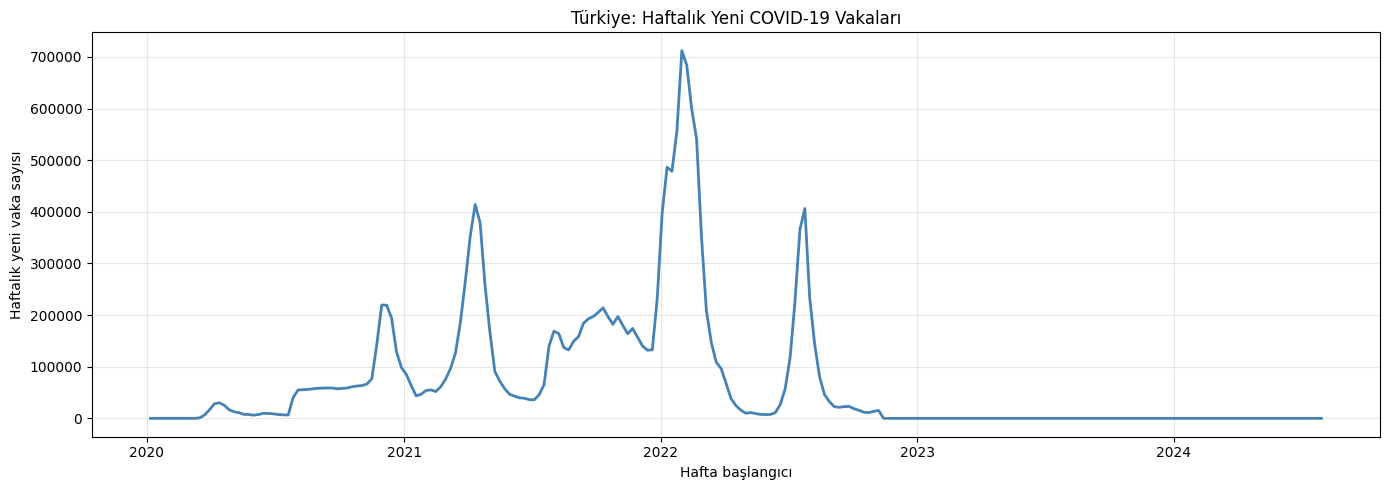

In [23]:
#Türkiye içine vaka eğilimi nasıl değişmiş
turkey_weekly = (
    weekly_cases_complete[
        weekly_cases_complete['location'] == 'Turkey'
    ]
    .sort_values('hafta_baslangici')
)

plt.figure(figsize=(14, 5))#grafiğin genişliği ve yüksekliği

plt.plot(
    turkey_weekly['hafta_baslangici'],
    turkey_weekly['mevcut_vaka_toplami'],
    color='steelblue',#çizginin rengi
    linewidth=2#çizginin kalınlığı
)

plt.title('Türkiye: Haftalık Yeni COVID-19 Vakaları')
plt.xlabel('Hafta başlangıcı')
plt.ylabel('Haftalık yeni vaka sayısı')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [24]:
#2023-2024 yılları arasında Türkiye nerdeyse  0 değerinde.Bunun nedenini inceliyoruz.
turkey_consistency = (
    df_countries[
        df_countries['location'] == 'Turkey'
    ][
        ['date', 'total_cases', 'new_cases']
    ]
    .sort_values('date')
    .copy()
)

turkey_consistency['total_cases_degisim'] = (
    turkey_consistency['total_cases'].diff()
)

print(
    turkey_consistency.tail(30).to_string(index=False)
)

      date  total_cases  new_cases  total_cases_degisim
2024-07-06   17004717.0        0.0                  0.0
2024-07-07   17004717.0        0.0                  0.0
2024-07-08   17004717.0        0.0                  0.0
2024-07-09   17004717.0        0.0                  0.0
2024-07-10   17004717.0        0.0                  0.0
2024-07-11   17004717.0        0.0                  0.0
2024-07-12   17004717.0        0.0                  0.0
2024-07-13   17004717.0        0.0                  0.0
2024-07-14   17004718.0        1.0                  1.0
2024-07-15   17004718.0        0.0                  0.0
2024-07-16   17004718.0        0.0                  0.0
2024-07-17   17004718.0        0.0                  0.0
2024-07-18   17004718.0        0.0                  0.0
2024-07-19   17004718.0        0.0                  0.0
2024-07-20   17004718.0        0.0                  0.0
2024-07-21   17004718.0        0.0                  0.0
2024-07-22   17004718.0        0.0              

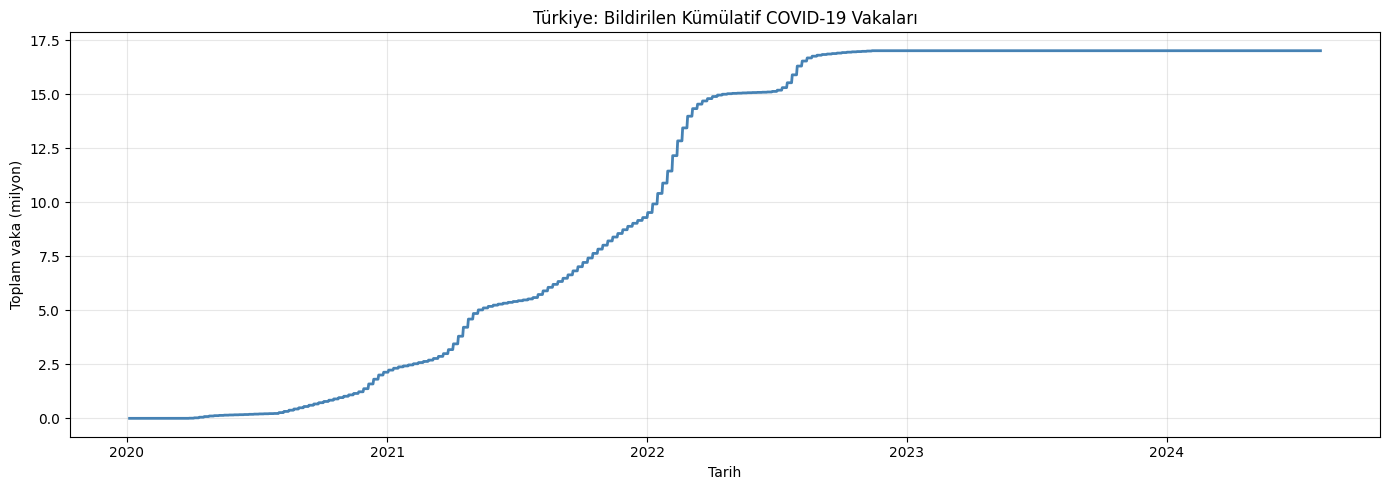

In [25]:
#Türkiye için toplam kümülatif vaka grafiği 
turkey_total_cases = (
    df_countries.loc[
        df_countries['location'] == 'Turkey',
        ['date', 'total_cases']
    ]
    .sort_values('date')
    .copy()
)

plt.figure(figsize=(14, 5))

plt.plot(
    turkey_total_cases['date'],
    turkey_total_cases['total_cases'] / 1_000_000,
    color='steelblue',
    linewidth=2
)

plt.title('Türkiye: Bildirilen Kümülatif COVID-19 Vakaları')
plt.xlabel('Tarih')
plt.ylabel('Toplam vaka (milyon)')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [26]:
#Ülkeler arası aynı tarihte vaka sayıları nasıl değişmiş inceliyoruz
comparison_date = pd.Timestamp('2024-08-04')

case_comparison = df_countries.loc[
    df_countries['date'] == comparison_date,
    [
        'location',
        'total_cases',
        'total_cases_per_million'
    ]
].copy()

print("Seçilen tarihteki ülke sayısı:", len(case_comparison))

print(
    "Eksik kayıt sayıları:",
    case_comparison[
        ['total_cases', 'total_cases_per_million']
    ].isna().sum(),
    sep='\n'
)

case_comparison_valid = case_comparison.dropna(
    subset=['total_cases', 'total_cases_per_million']
).copy()

print(
    "İki gösterge için de verisi bulunan ülke sayısı:",
    len(case_comparison_valid)
)

Seçilen tarihteki ülke sayısı: 197
Eksik kayıt sayıları:
total_cases                1
total_cases_per_million    1
dtype: int64
İki gösterge için de verisi bulunan ülke sayısı: 196


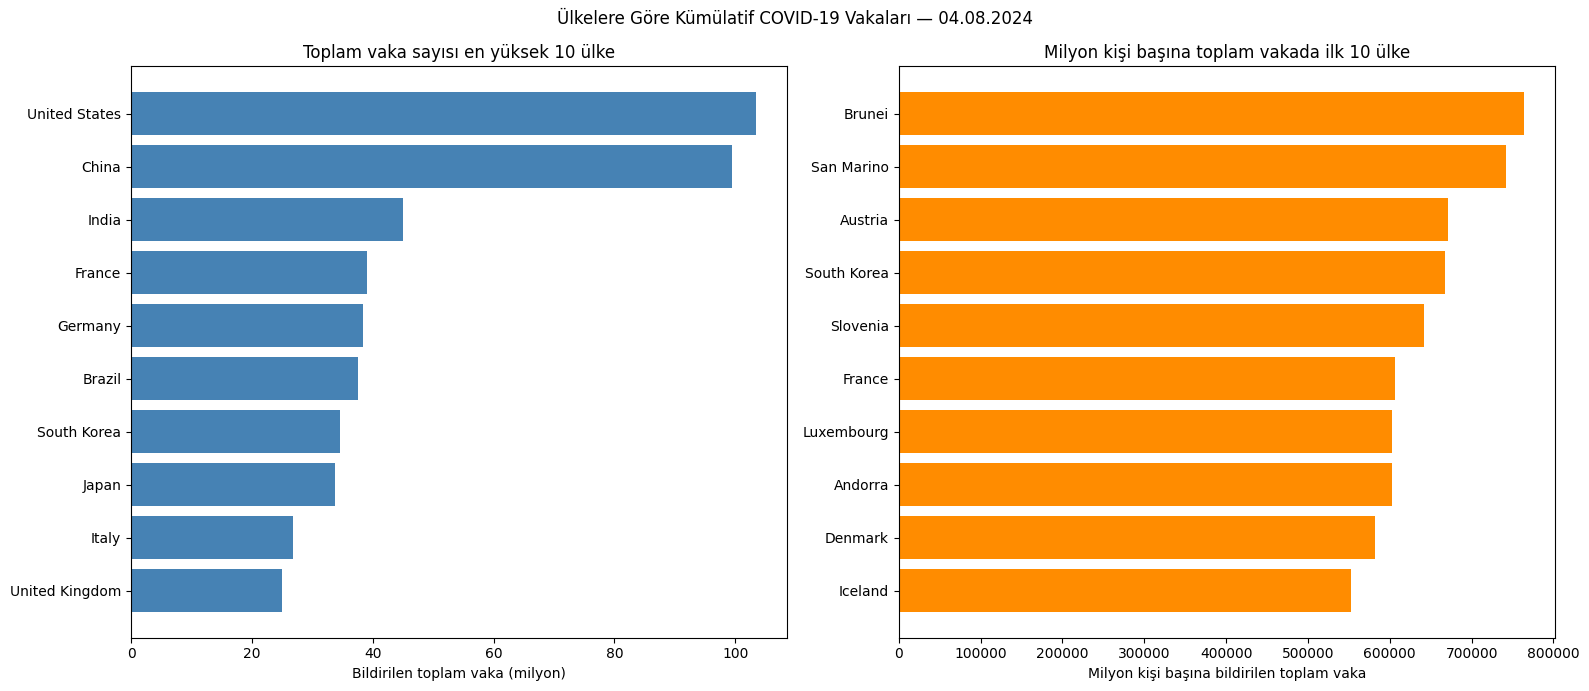

In [27]:
top_total_cases = (
    case_comparison_valid
    .nlargest(10, 'total_cases')#total_cases değeri en yüksek 10 ülkeyi seçiyoruz
    .sort_values('total_cases')
)

top_cases_per_million = (
    case_comparison_valid
    .nlargest(10, 'total_cases_per_million')#total_cases değeri nüfusa göre en yüksek 10 ülkeyi seçiyoruz
    .sort_values('total_cases_per_million')
)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

axes[0].barh(
    top_total_cases['location'],
    top_total_cases['total_cases'] / 1_000_000,
    color='steelblue'
)

axes[0].set_title('Toplam vaka sayısı en yüksek 10 ülke')
axes[0].set_xlabel('Bildirilen toplam vaka (milyon)')

axes[1].barh(
    top_cases_per_million['location'],
    top_cases_per_million['total_cases_per_million'],
    color='darkorange'
)

axes[1].set_title('Milyon kişi başına toplam vakada ilk 10 ülke')
axes[1].set_xlabel('Milyon kişi başına bildirilen toplam vaka')

fig.suptitle(
    f'Ülkelere Göre Kümülatif COVID-19 Vakaları — '
    f'{comparison_date:%d.%m.%Y}'
)

plt.tight_layout()
plt.show()

4 Ağustos 2024 tarihli kayıtlarda toplam vaka sayısında ABD, Çin ve Hindistan öne çıkarken, milyon kişi başına toplam vakada Brunei, San Marino ve Avusturya ilk sıralardadır. Nüfusa göre hesaplama ülke sıralamasını değiştirmektedir. Sonuçlar bildirilen vakaları göstermekte olup tek başına ülkelerin salgın yönetimi başarısını ölçmez.

In [28]:
#her haftada kaç ülkenin verisi tam
weekly_country_coverage = (
    weekly_cases_complete
    .groupby('hafta_baslangici')['location']
    .nunique()
    .reset_index(name='ulke_sayisi')
    .sort_values(
        ['ulke_sayisi', 'hafta_baslangici'],
        ascending=[False, False]
    )
)

print(weekly_country_coverage.head(15).to_string(index=False))

hafta_baslangici  ulke_sayisi
      2023-05-08          196
      2023-05-01          196
      2023-04-24          196
      2023-04-17          196
      2023-04-10          196
      2023-04-03          196
      2023-03-27          196
      2023-03-20          196
      2023-03-13          196
      2023-03-06          196
      2023-02-27          196
      2023-02-20          196
      2023-02-13          196
      2023-01-30          196
      2023-01-23          196


In [29]:
selected_week = pd.Timestamp('2023-05-08')

week_case_comparison = weekly_cases_complete.loc[
    weekly_cases_complete['hafta_baslangici'] == selected_week,
    [
        'location',
        'mevcut_vaka_toplami',
        'haftalik_vaka_milyon_basina'
    ]
].copy()

print(
    week_case_comparison
    .sort_values('haftalik_vaka_milyon_basina', ascending=False)
    .head(10)
    .to_string(index=False)
)

   location  mevcut_vaka_toplami  haftalik_vaka_milyon_basina
     Brunei               6861.0                 15280.555543
  Singapore              22624.0                  4013.466685
South Korea             130356.0                  2515.757353
New Zealand              11103.0                  2141.249986
  Australia              31859.0                  1217.041717
  Mauritius               1538.0                  1183.552165
 San Marino                 37.0                  1098.248738
   Barbados                228.0                   809.526853
     Greece               7212.0                   694.465040
      Qatar               1539.0                   571.029757


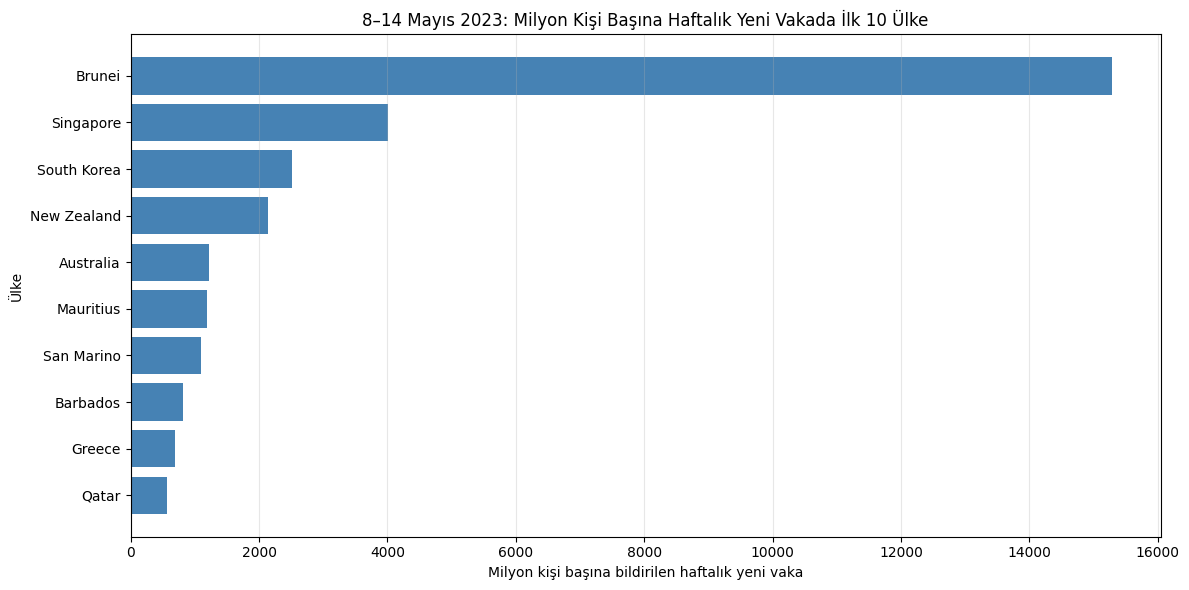

In [30]:
#belirtilen tarihte ülkelerde  ilk 10 ülkede nasıl değişmiş vakalar inceliyoruz
top_weekly_cases = (
    week_case_comparison
    .nlargest(10, 'haftalik_vaka_milyon_basina')
    .sort_values('haftalik_vaka_milyon_basina')
)

plt.figure(figsize=(12, 6))

plt.barh(
    top_weekly_cases['location'],
    top_weekly_cases['haftalik_vaka_milyon_basina'],
    color='steelblue'
)

plt.title('8–14 Mayıs 2023: Milyon Kişi Başına Haftalık Yeni Vakada İlk 10 Ülke')
plt.xlabel('Milyon kişi başına bildirilen haftalık yeni vaka')
plt.ylabel('Ülke')
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

In [31]:
#her ülkenin pazar günündeki total_cases değerini inceliyoruz
week_end_totals = df_countries.loc[
    df_countries['date'].dt.dayofweek == 6,
    ['location', 'date', 'total_cases']
].copy()

week_end_totals = week_end_totals.rename(
    columns={
        'date': 'hafta_sonu',
        'total_cases': 'hafta_sonu_toplam_vaka'
    }
)

weekly_cases_final = weekly_cases_analysis.copy()

weekly_cases_final['hafta_sonu'] = (
    weekly_cases_final['hafta_baslangici']
    + pd.Timedelta(days=6)
)

weekly_cases_final = weekly_cases_final.merge(
    week_end_totals,
    on=['location', 'hafta_sonu'],
    how='left',
    validate='one_to_one'
)

weekly_cases_final['hafta_sonu_toplam_eksik'] = (
    weekly_cases_final['hafta_sonu_toplam_vaka'].isna()
)

print(
    weekly_cases_final[
        [
            'location',
            'hafta_baslangici',
            'hafta_sonu',
            'mevcut_vaka_toplami',
            'tam_hafta',
            'hafta_sonu_toplam_vaka',
            'hafta_sonu_toplam_eksik'
        ]
    ].head(15).to_string(index=False)
)

   location hafta_baslangici hafta_sonu  mevcut_vaka_toplami  tam_hafta  hafta_sonu_toplam_vaka  hafta_sonu_toplam_eksik
Afghanistan       2019-12-30 2020-01-05                  0.0      False                     0.0                    False
Afghanistan       2020-01-06 2020-01-12                  0.0       True                     0.0                    False
Afghanistan       2020-01-13 2020-01-19                  0.0       True                     0.0                    False
Afghanistan       2020-01-20 2020-01-26                  0.0       True                     0.0                    False
Afghanistan       2020-01-27 2020-02-02                  0.0       True                     0.0                    False
Afghanistan       2020-02-03 2020-02-09                  0.0       True                     0.0                    False
Afghanistan       2020-02-10 2020-02-16                  0.0       True                     0.0                    False
Afghanistan       2020-02-17 202

In [32]:
weekly_cases_final['haftalik_yeni_vaka'] = (
    weekly_cases_final['mevcut_vaka_toplami']
    .where(weekly_cases_final['tam_hafta'])
)

weekly_cases_final['haftalik_vaka_milyon_basina'] = (
    weekly_cases_final['haftalik_yeni_vaka']
    / weekly_cases_final['population']
    * 1_000_000
)

print(
    weekly_cases_final[
        [
            'location',
            'hafta_baslangici',
            'tam_hafta',
            'haftalik_yeni_vaka',
            'haftalik_vaka_milyon_basina',
            'hafta_sonu_toplam_vaka'
        ]
    ].head(15).to_string(index=False)
)

   location hafta_baslangici  tam_hafta  haftalik_yeni_vaka  haftalik_vaka_milyon_basina  hafta_sonu_toplam_vaka
Afghanistan       2019-12-30      False                 NaN                          NaN                     0.0
Afghanistan       2020-01-06       True                 0.0                     0.000000                     0.0
Afghanistan       2020-01-13       True                 0.0                     0.000000                     0.0
Afghanistan       2020-01-20       True                 0.0                     0.000000                     0.0
Afghanistan       2020-01-27       True                 0.0                     0.000000                     0.0
Afghanistan       2020-02-03       True                 0.0                     0.000000                     0.0
Afghanistan       2020-02-10       True                 0.0                     0.000000                     0.0
Afghanistan       2020-02-17       True                 0.0                     0.000000        

In [33]:
weekly_cases_final['veri_durumu'] = (
    weekly_cases_final['dolu_gun'].astype(str)
    + '/7 gün dolu — '
    + weekly_cases_final['eksik_gun'].astype(str)
    + ' gün eksik'
)

weekly_cases_final.loc[
    weekly_cases_final['tam_hafta'],
    'veri_durumu'
] = 'Tam hafta — 7/7 gün dolu'

weekly_cases_final.loc[
    weekly_cases_final['dolu_gun'] == 0,
    'veri_durumu'
] = 'Veri yok — 0/7 gün dolu'

print(
    weekly_cases_final[
        [
            'location',
            'hafta_baslangici',
            'mevcut_vaka_toplami',
            'veri_durumu'
        ]
    ].head(15).to_string(index=False)
)

   location hafta_baslangici  mevcut_vaka_toplami                veri_durumu
Afghanistan       2019-12-30                  0.0 1/7 gün dolu — 6 gün eksik
Afghanistan       2020-01-06                  0.0   Tam hafta — 7/7 gün dolu
Afghanistan       2020-01-13                  0.0   Tam hafta — 7/7 gün dolu
Afghanistan       2020-01-20                  0.0   Tam hafta — 7/7 gün dolu
Afghanistan       2020-01-27                  0.0   Tam hafta — 7/7 gün dolu
Afghanistan       2020-02-03                  0.0   Tam hafta — 7/7 gün dolu
Afghanistan       2020-02-10                  0.0   Tam hafta — 7/7 gün dolu
Afghanistan       2020-02-17                  0.0   Tam hafta — 7/7 gün dolu
Afghanistan       2020-02-24                  1.0   Tam hafta — 7/7 gün dolu
Afghanistan       2020-03-02                  0.0   Tam hafta — 7/7 gün dolu
Afghanistan       2020-03-09                  6.0   Tam hafta — 7/7 gün dolu
Afghanistan       2020-03-16                 17.0   Tam hafta — 7/7 gün dolu

In [34]:
print(
    weekly_cases_final[
        [
            'location',
            'hafta_baslangici',
            'mevcut_vaka_toplami',
            'veri_durumu',
            'hafta_sonu_toplam_vaka'
        ]
    ].head(15).to_string(index=False)
)

   location hafta_baslangici  mevcut_vaka_toplami                veri_durumu  hafta_sonu_toplam_vaka
Afghanistan       2019-12-30                  0.0 1/7 gün dolu — 6 gün eksik                     0.0
Afghanistan       2020-01-06                  0.0   Tam hafta — 7/7 gün dolu                     0.0
Afghanistan       2020-01-13                  0.0   Tam hafta — 7/7 gün dolu                     0.0
Afghanistan       2020-01-20                  0.0   Tam hafta — 7/7 gün dolu                     0.0
Afghanistan       2020-01-27                  0.0   Tam hafta — 7/7 gün dolu                     0.0
Afghanistan       2020-02-03                  0.0   Tam hafta — 7/7 gün dolu                     0.0
Afghanistan       2020-02-10                  0.0   Tam hafta — 7/7 gün dolu                     0.0
Afghanistan       2020-02-17                  0.0   Tam hafta — 7/7 gün dolu                     0.0
Afghanistan       2020-02-24                  1.0   Tam hafta — 7/7 gün dolu               

In [35]:
print(
    weekly_cases_final.loc[
        ~weekly_cases_final['tam_hafta'],
        [
            'location',
            'hafta_baslangici',
            'mevcut_vaka_toplami',
            'dolu_gun',
            'eksik_gun',
            'veri_durumu'
        ]
    ].head(20).to_string(index=False)
)

           location hafta_baslangici  mevcut_vaka_toplami  dolu_gun  eksik_gun                veri_durumu
        Afghanistan       2019-12-30                  0.0         1          6 1/7 gün dolu — 6 gün eksik
            Albania       2019-12-30                  0.0         1          6 1/7 gün dolu — 6 gün eksik
            Algeria       2019-12-30                  0.0         1          6 1/7 gün dolu — 6 gün eksik
            Andorra       2019-12-30                  0.0         1          6 1/7 gün dolu — 6 gün eksik
             Angola       2019-12-30                  0.0         1          6 1/7 gün dolu — 6 gün eksik
Antigua and Barbuda       2019-12-30                  0.0         1          6 1/7 gün dolu — 6 gün eksik
          Argentina       2019-12-30                  0.0         1          6 1/7 gün dolu — 6 gün eksik
            Armenia       2019-12-30                  0.0         1          6 1/7 gün dolu — 6 gün eksik
          Australia       2019-12-30          

In [36]:
from pathlib import Path

def find_project_root():
    current = Path.cwd().resolve()
    for candidate in (current, *current.parents):
        if (candidate / 'data').is_dir() and (candidate / 'notebooks').is_dir():
            return candidate
    raise FileNotFoundError('Proje kök klasörü bulunamadı.')

PROJECT_ROOT = find_project_root()

output_path = PROJECT_ROOT / 'data' / 'processed' / 'weekly_cases.csv'
output_path.parent.mkdir(parents=True, exist_ok=True)

weekly_cases_final.to_csv(output_path, index=False, encoding='utf-8-sig')
print('Haftalık vaka tablosu kaydedildi:', output_path.name)


Haftalık vaka tablosu kaydedildi: weekly_cases.csv
